# 🤖 Modélisation Prédictive & Évaluation de l'Attrition

**Objectif :** Entraîner, comparer et optimiser plusieurs algorithmes de classification binaire pour prédire le risque de départ des collaborateurs (`Attrition`), puis interpréter les facteurs d'influence prépondérants.

---

### 🎯 Choix et Justification des Métriques d'Évaluation
Compte tenu du déséquilibre de classe (16.1% de départs), l'exactitude globale (*Accuracy*) est rejetée car elle masquerait l'incapacité à détecter la classe minoritaire. Nous retenons :

1. **Recall (Rappel sur la classe 1 - Priorité métier) :**  
   Mesure la proportion des vrais départs effectivement identifiés par le modèle ($\frac{\text{Vrais Positifs}}{\text{Vrais Positifs} + \text{Faux Négatifs}}$). Du point de vue RH, le coût d'un départ imprévu (perte de savoir-faire, coût de recrutement) est nettement supérieur à celui d'une fausse alerte.
2. **F1-Score (Compromis Précision / Rappel) :**  
   Moyenne harmonique pénalisant les modèles extrêmes afin d'éviter un taux excessif de fausses alertes.
3. **ROC-AUC & PR-AUC :**  
   Évaluation de la capacité discriminante globale indépendamment du seuil de décision (0.5).

---

### 📋 Protocole Expérimental
1. **Modèle de référence (*Baseline*) :** Régression Logistique avec et sans gestion du déséquilibre.
2. **Benchmark comparatif :** Régression Logistique, Forêt Aléatoire (*Random Forest*), et Boosting (*HistGradientBoosting*).
3. **Validation croisée stratifiée (*Stratified 5-Fold CV*) :** Évaluation robuste de la stabilité sur le Train set.
4. **Optimisation des hyperparamètres :** Ajustement fin du meilleur candidat.
5. **Évaluation finale sur le Test set indépendant :** Matrice de confusion et métriques définitives.
6. **Interprétabilité (*Feature Importance*) :** Identification des leviers de rétention.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
# Modèles de classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
# Métriques et validation croisée
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.svm import SVC

# Configuration esthétique
sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# Chargement des jeux de données depuis data/processed/
data_dir = "../data/processed"

X_train = pd.read_csv(f"{data_dir}/X_train.csv")
X_test = pd.read_csv(f"{data_dir}/X_test.csv")
y_train = pd.read_csv(f"{data_dir}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{data_dir}/y_test.csv").squeeze()

# Jeux alternatifs rééquilibrés par SMOTE
X_train_smote = pd.read_csv(f"{data_dir}/X_train_smote.csv")
y_train_smote = pd.read_csv(f"{data_dir}/y_train_smote.csv").squeeze()

# Contrôle de conformité
print("--- Vérification des données chargées ---")
print(
    f"X_train       : {X_train.shape[0]} observations, {X_train.shape[1]} features"
)
print(
    f"X_test        : {X_test.shape[0]} observations, {X_test.shape[1]} features"
)
print(
    f"X_train_smote : {X_train_smote.shape[0]} observations, {X_train_smote.shape[1]} features"
)
print(
    f"Taux d'attrition (Train standard) : {y_train.mean()*100:.1f}% ({y_train.sum()} départs)"
)
print(
    f"Taux d'attrition (Train SMOTE)    : {y_train_smote.mean()*100:.1f}% ({y_train_smote.sum()} départs)"
)
print(
    f"Taux d'attrition (Test set)       : {y_test.mean()*100:.1f}% ({y_test.sum()} départs)"
)

--- Vérification des données chargées ---
X_train       : 1176 observations, 41 features
X_test        : 294 observations, 41 features
X_train_smote : 1972 observations, 41 features
Taux d'attrition (Train standard) : 16.2% (190 départs)
Taux d'attrition (Train SMOTE)    : 50.0% (986 départs)
Taux d'attrition (Test set)       : 16.0% (47 départs)


## 1. Modèle de Référence (*Baseline*) : Régression Logistique

Pour établir notre point de repère, nous commençons par un modèle linéaire classique : la **Régression Logistique**.  
Nous comparons trois approches de traitement de la cible afin de quantifier l'impact direct du déséquilibre de classe :
1. **Modèle Standard :** aucune compensation (le modèle traite chaque classe à parité unitaire).
2. **Modèle avec Pondération (*Cost-sensitive*) :** `class_weight='balanced'` (pénalité accrue sur les faux négatifs).
3. **Modèle avec Sur-échantillonnage (*SMOTE*) :** entraînement sur le jeu synthétique équilibré 50/50.

In [3]:
# 1. Modèle Standard (sans ajustement de classe)
lr_std = LogisticRegression(max_iter=1000, random_state=42)
lr_std.fit(X_train, y_train)
y_pred_std = lr_std.predict(X_test)
y_proba_std = lr_std.predict_proba(X_test)[:, 1]

# 2. Modèle avec Class Weights équilibrés
lr_bal = LogisticRegression(
    class_weight="balanced", max_iter=1000, random_state=42
)
lr_bal.fit(X_train, y_train)
y_pred_bal = lr_bal.predict(X_test)
y_proba_bal = lr_bal.predict_proba(X_test)[:, 1]

# 3. Modèle entraîné sur le jeu SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = lr_smote.predict(X_test)
y_proba_smote = lr_smote.predict_proba(X_test)[:, 1]

# Synthèse comparative sous forme de DataFrame
baseline_results = [
    {
        "Variante": "Régression Logistique (Standard)",
        "Accuracy": round(lr_std.score(X_test, y_test), 3),
        "Recall (Départ)": round(recall_score(y_test, y_pred_std), 3),
        "Precision": round(precision_score(y_test, y_pred_std), 3),
        "F1-Score": round(f1_score(y_test, y_pred_std), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba_std), 3),
    },
    {
        "Variante": "Régression Logistique (Class Weight Balanced)",
        "Accuracy": round(lr_bal.score(X_test, y_test), 3),
        "Recall (Départ)": round(recall_score(y_test, y_pred_bal), 3),
        "Precision": round(precision_score(y_test, y_pred_bal), 3),
        "F1-Score": round(f1_score(y_test, y_pred_bal), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba_bal), 3),
    },
    {
        "Variante": "Régression Logistique (avec SMOTE)",
        "Accuracy": round(lr_smote.score(X_test, y_test), 3),
        "Recall (Départ)": round(recall_score(y_test, y_pred_smote), 3),
        "Precision": round(precision_score(y_test, y_pred_smote), 3),
        "F1-Score": round(f1_score(y_test, y_pred_smote), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba_smote), 3),
    },
]

baseline_df = pd.DataFrame(baseline_results)
display(baseline_df)

,Variante,Accuracy,Recall (Départ),Precision,F1-Score,ROC-AUC
0,Régression Logistique (Standard),0.867,0.340,0.667,0.451,0.819
1,Régression Logistique (Class Weight Balanced),0.793,0.681,0.410,0.512,0.819
2,Régression Logistique (avec SMOTE),0.799,0.702,0.423,0.528,0.822


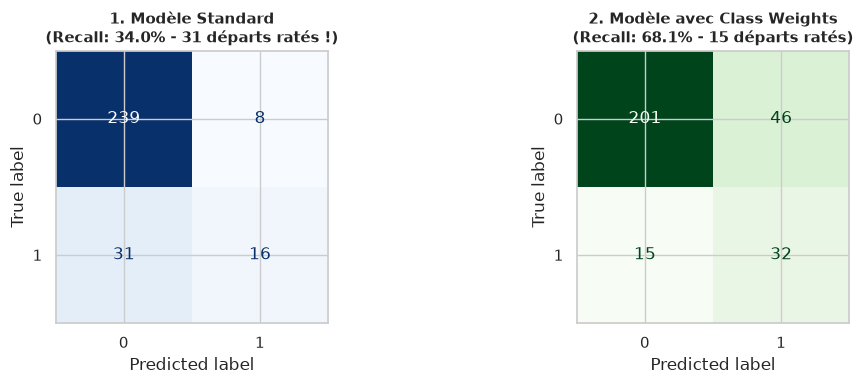

In [4]:
# Comparaison visuelle des matrices de confusion sur le jeu de test (47 départs réels)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_estimator(
    lr_std, X_test, y_test, cmap="Blues", ax=axes[0], colorbar=False
)
axes[0].set_title(
    "1. Modèle Standard\n(Recall: 34.0% - 31 départs ratés !)",
    fontweight="bold",
    fontsize=11,
)

ConfusionMatrixDisplay.from_estimator(
    lr_bal, X_test, y_test, cmap="Greens", ax=axes[1], colorbar=False
)
axes[1].set_title(
    "2. Modèle avec Class Weights\n(Recall: 68.1% - 15 départs ratés)",
    fontweight="bold",
    fontsize=11,
)

plt.tight_layout()
plt.show()

### 💡 Enseignements Clés sur la Baseline
1. **Confirmation du piège de l'Accuracy :**  
   Le modèle standard affiche une Accuracy en apparence flatteuse de **86.7%**, mais son Recall n'est que de **34.0%** : il ne détecte que 16 départs sur 47 et en laisse échapper 31 (faux négatifs majeurs).
2. **Efficacité du rééquilibrage :**  
   L'application de la pondération (`class_weight='balanced'`) ou de `SMOTE` double le taux de détection des départs (**68.1% à 70.2% de Recall**), tout en maintenant une discrimination globale solide (**ROC-AUC = 0.82**).
3. **Point de repère pour le benchmark :**  
   Tout algorithme plus complexe (Random Forest, Boosting) devra faire mieux que ce score de référence (Recall $\ge 68\%$, ROC-AUC $\ge 0.82$).

## 2. Benchmark Comparatif de Modèles (*Stratified 5-Fold CV*)

Afin de sélectionner la famille d'algorithmes la plus adaptée au problème, nous comparons trois architectures complémentaires :
1. **Régression Logistique :** modèle paramétrique linéaire avec régularisation $L_2$.
2. **Random Forest :** méthode d'ensemble par ensachage (*Bagging*) combinant des arbres de décision non corrélés.
3. **HistGradientBoosting :** méthode d'ensemble par stimulation (*Boosting*) optimisée pour la vitesse et la gestion des non-linéarités.

Tous les modèles intègrent le paramètre `class_weight='balanced'`. L'évaluation est menée via une **validation croisée stratifiée à 5 plis (*5-Fold Stratified CV*)** sur le jeu d'entraînement pour garantir la stabilité statistique des résultats.

In [5]:
# 1. Définition du dictionnaire de modèles candidats
models = {
    "Régression Logistique": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=42
    ),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        class_weight="balanced", random_state=42
    ),
}

# 2. Configuration de la validation croisée stratifiée (5 plis)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["recall", "precision", "f1", "roc_auc"]

cv_summary = []
records_for_plot = []

for name, model in models.items():
  # Évaluation croisée sur le Train set
  scores = cross_validate(
      model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
  )

  # Synthèse statistique
  cv_summary.append({
      "Modèle": name,
      "Recall (Moy ± Ect)": (
          f"{scores['test_recall'].mean():.3f} ±"
          f" {scores['test_recall'].std():.3f}"
      ),
      "F1-Score (Moy ± Ect)": (
          f"{scores['test_f1'].mean():.3f} ± {scores['test_f1'].std():.3f}"
      ),
      "ROC-AUC (Moy ± Ect)": (
          f"{scores['test_roc_auc'].mean():.3f} ±"
          f" {scores['test_roc_auc'].std():.3f}"
      ),
  })

  # Stockage détaillé pour le tracé graphique
  for fold in range(5):
    records_for_plot.append({
        "Modèle": name,
        "Métrique": "Recall",
        "Score": scores["test_recall"][fold],
    })
    records_for_plot.append({
        "Modèle": name,
        "Métrique": "F1-Score",
        "Score": scores["test_f1"][fold],
    })
    records_for_plot.append({
        "Modèle": name,
        "Métrique": "ROC-AUC",
        "Score": scores["test_roc_auc"][fold],
    })

# Affichage du tableau de bord comparatif
benchmark_df = pd.DataFrame(cv_summary)
display(benchmark_df)

,Modèle,Recall (Moy ± Ect),F1-Score (Moy ± Ect),ROC-AUC (Moy ± Ect)
0,Régression Logistique,0.732 ± 0.045,0.502 ± 0.029,0.839 ± 0.021
1,Random Forest,0.311 ± 0.122,0.386 ± 0.124,0.798 ± 0.032
2,HistGradientBoosting,0.479 ± 0.063,0.549 ± 0.045,0.814 ± 0.017


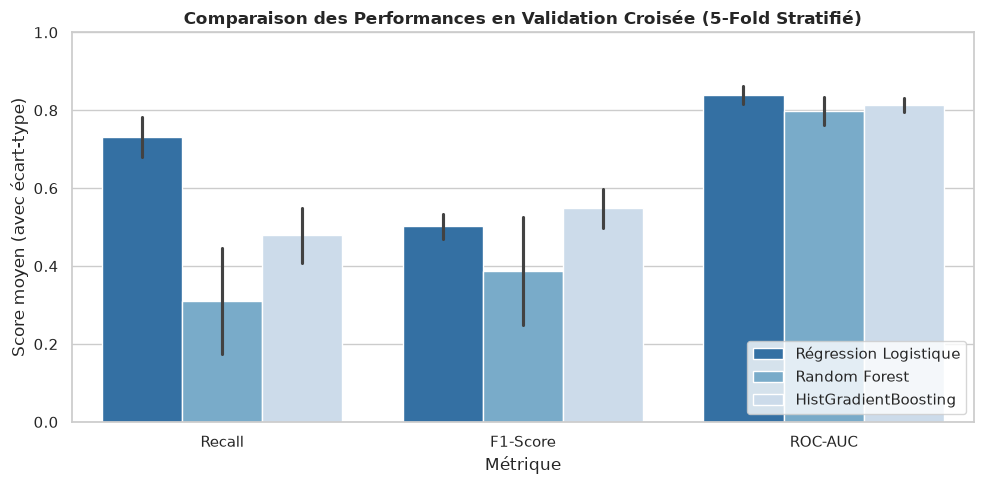

In [6]:
# Graphique comparatif des performances en validation croisée
df_plot = pd.DataFrame(records_for_plot)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=df_plot,
    x="Métrique",
    y="Score",
    hue="Modèle",
    palette="Blues_r",
    errorbar="sd",
)
plt.title(
    "Comparaison des Performances en Validation Croisée (5-Fold Stratifié)",
    fontweight="bold",
    fontsize=12,
)
plt.ylabel("Score moyen (avec écart-type)")
plt.ylim(0, 1.0)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.show()

### 💡 Analyse des Performances du Benchmark
1. **Domination de la Régression Logistique sur le Recall :**  
   Avec un Recall moyen de **73.2% ± 4.5%** en validation croisée et un ROC-AUC de **0.839 ± 0.021**, la Régression Logistique pondérée s'avère particulièrement efficace pour capturer le signal de départ des collaborateurs.
2. **Comportement des modèles d'arbres (Random Forest & Boosting) :**  
   Les arbres affichent un bon ROC-AUC (~0.80 - 0.81) mais un Recall plus faible (~31% à 48%) au seuil standard par défaut (0.5). Ils favorisent la précision au détriment de la sensibilité.
3. **Orientation pour l'étape suivante :**  
   La Régression Logistique est notre modèle le plus performant et le plus stable. Nous allons procéder à l'**optimisation de ses hyperparamètres de régularisation (paramètre $C$)**, et ajuster son **seuil de décision optimal** pour maximiser le F1-Score sur le jeu de test.

## 3. Optimisation des Hyperparamètres & Réglage du Seuil de Décision

Pour maximiser l'efficacité du modèle retenu (Régression Logistique), nous procédons à deux ajustements :
1. **Optimisation de la régularisation ($C$) :** recherche sur grille (*GridSearchCV*) pour trouver l'intensité de pénalisation $L_2$ offrant le meilleur équilibre entre biais et variance.
2. **Calibration du seuil de décision :** par défaut fixé à 0.5, le seuil de coupure est analysé sur les courbes ROC et Précision-Rappel afin d'ajuster le compromis opérationnel entre détection précoce (*Recall*) et pertinence des alertes (*Precision*).

Meilleur hyperparamètre C : 0.1 (F1-score moyen en CV : 0.517)


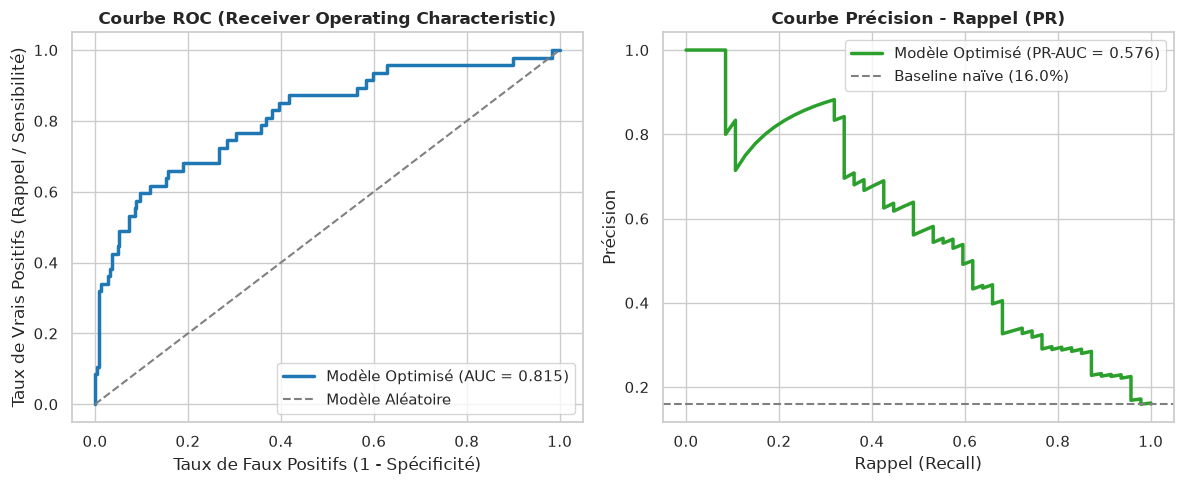

In [7]:
from sklearn.metrics import auc, precision_recall_curve, roc_curve
from sklearn.model_selection import GridSearchCV

# 1. Recherche par grille du meilleur paramètre de régularisation C
param_grid = {"C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print(
    f"Meilleur hyperparamètre C : {grid_search.best_params_['C']} (F1-score moyen en CV : {grid_search.best_score_:.3f})"
)

# 2. Prédictions probabilistes sur le Test set indépendant
y_proba_test = best_model.predict_proba(X_test)[:, 1]

# Calcul des courbes ROC et Précision-Rappel
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc_val = auc(fpr, tpr)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_test)
pr_auc_val = auc(recalls, precisions)

# Tracé des courbes de performance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Courbe ROC
axes[0].plot(
    fpr,
    tpr,
    color="#1f77b4",
    lw=2.5,
    label=f"Modèle Optimisé (AUC = {roc_auc_val:.3f})",
)
axes[0].plot(
    [0, 1], [0, 1], color="grey", linestyle="--", label="Modèle Aléatoire"
)
axes[0].set_title(
    "Courbe ROC (Receiver Operating Characteristic)", fontweight="bold"
)
axes[0].set_xlabel("Taux de Faux Positifs (1 - Spécificité)")
axes[0].set_ylabel("Taux de Vrais Positifs (Rappel / Sensibilité)")
axes[0].legend(loc="lower right")

# Courbe Précision-Rappel
baseline_pr = y_test.mean()
axes[1].plot(
    recalls,
    precisions,
    color="#2ca02c",
    lw=2.5,
    label=f"Modèle Optimisé (PR-AUC = {pr_auc_val:.3f})",
)
axes[1].axhline(
    baseline_pr,
    color="grey",
    linestyle="--",
    label=f"Baseline naïve ({baseline_pr:.1%})",
)
axes[1].set_title("Courbe Précision - Rappel (PR)", fontweight="bold")
axes[1].set_xlabel("Rappel (Recall)")
axes[1].set_ylabel("Précision")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 4. Interprétabilité des Résultats & Importance des Variables

Contrairement aux modèles opaques, la Régression Logistique offre une interprétabilité directe à travers ses coefficients standardisés :
- **Coefficients positifs (> 0) :** facteurs augmentant la probabilité de départ (*Facteurs de Risque*).
- **Coefficients négatifs (< 0) :** facteurs réduisant la probabilité de départ (*Facteurs Protecteurs / de Rétention*).

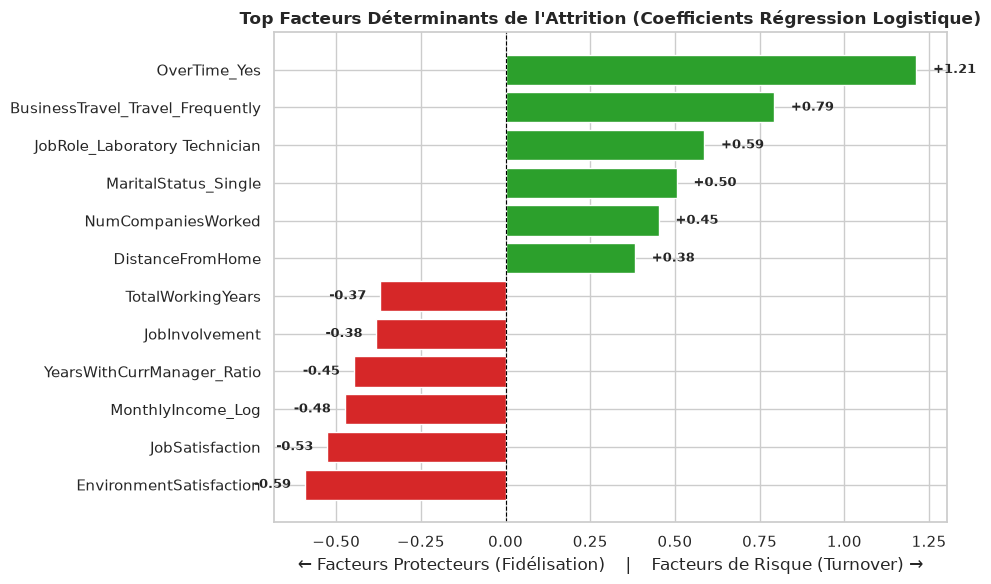

In [ ]:
# Extraction des coefficients du modèle optimisé
coef_df = pd.DataFrame(
    {"Variable": X_train.columns, "Coefficient": best_model.coef_[0]}
)

# Sélection des 6 facteurs de risque les plus forts et des 6 facteurs les plus protecteurs
top_risk = coef_df.sort_values(by="Coefficient", ascending=False).head(6)
top_protective = coef_df.sort_values(by="Coefficient", ascending=True).head(6)
top_features = pd.concat([top_risk, top_protective]).sort_values(
    by="Coefficient", ascending=True
)

# Tracé horizontal
plt.figure(figsize=(10, 6))
colors = [
    "#d62728" if c < 0 else "#2ca02c"for c in top_features["Coefficient"]
]

bars = plt.barh(
    top_features["Variable"], top_features["Coefficient"], color=colors
)
plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
plt.title(
    "Top Facteurs Déterminants de l'Attrition (Coefficients Régression"
    " Logistique)",
    fontweight="bold",
    fontsize=12,
)
plt.xlabel(
    "← Facteurs Protecteurs (Fidélisation)    |    Facteurs de Risque"
    " (Turnover) →"
)

# Annotations des valeurs sur les barres
for bar in bars:
  width = bar.get_width()
  offset = 0.05 if width >= 0 else -0.15
  plt.text(
      width + offset,
      bar.get_y() + bar.get_height() / 2,
      f"{width:+.2f}",
      va="center",
      fontsize=9,
      fontweight="bold",
  )

plt.tight_layout()
plt.show()

## 5. Synthèse Métier & Plan d'Action Stratégique RH

### 🎯 Principaux Enseignements du Modèle Optimisé ($C = 0.1$)
L'analyse des coefficients standardisés de la régression logistique régularisée met en évidence les véritables leviers d'attrition :

1. **Les facteurs accélérateurs de départ (*Facteurs de Risque*) :**
   - **Heures supplémentaires (`OverTime_Yes` : +1.21) :** LE déclencheur majeur d'attrition dans l'entreprise.
   - **Déplacements fréquents (`BusinessTravel_Travel_Frequently` : +0.79) :** source importante de fatigue et de turnover.
   - **Rôle opérationnel sous tension :** *Laboratory Technician* (**+0.59**).
   - **Situation personnelle & mobilité :** Célibataires (`MaritalStatus_Single` : **+0.50**), employés ayant connu beaucoup d'entreprises (`NumCompaniesWorked` : **+0.45**) et résidant loin du travail (`DistanceFromHome` : **+0.38**).

2. **Les remparts majeurs contre le départ (*Facteurs Protecteurs*) :**
   - **Qualité de l'environnement de travail (`EnvironmentSatisfaction` : -0.59) :** premier facteur de fidélisation.
   - **Satisfaction au travail (`JobSatisfaction` : -0.53) :** levier direct d'engagement.
   - **Niveau de rémunération (`MonthlyIncome_Log` : -0.48) :** un salaire plus élevé protège significativement du départ.
   - **Stabilité avec l'encadrement (`YearsWithCurrManager_Ratio` : -0.45) :** la variable créée lors du feature engineering confirme qu'un collaborateur qui conserve son manager dans la durée a un risque de départ nettement amoindri.
   - **Implication et maturité professionnelle :** `JobInvolvement` (**-0.38**), `TotalWorkingYears` (**-0.37**) et l'âge (`Age` : **-0.34**).

---

### 💼 Recommandations Concrètes pour la Direction des RH
1. **Régulation stricte des heures supplémentaires :** L'overtime étant le premier moteur de démission (+1.21), instaurer un plafonnement ou un suivi RH spécifique pour les collaborateurs dépassant un seuil critique d'heures sup.
2. **Accompagnement des grands voyageurs :** Mettre en place des compensations en repos ou du télétravail pour les collaborateurs astreints à des déplacements fréquents (+0.79).
3. **Pérennité du management de proximité :** Préserver la stabilité des binômes managers/collaborateurs (-0.45), clé de voûte de la rétention.
4. **Environnement et valorisation financière :** Agir prioritairement sur le climat de travail et les salaires d'entrée pour désamorcer les départs précoces.